# Arbitrage Validator

Scan persisted `book_state` checkpoints from the PoPs and surface simple cross-venue arbitrage candidates.

## Notebook Scope

This notebook performs a simple top-of-book replay over persisted venue checkpoints.

It:
- reads `.jsonl` and `.jsonl.gz` PoP outputs
- keeps only `book_state` records
- normalizes venue-specific symbol formats into one canonical symbol
- tracks the latest known book per `(symbol, venue)`
- compares the lowest ask against the highest bid across venues
- reports a candidate only when the spread is positive and both books are fresh enough

It does not yet model fees, slippage, inventory, or deeper depth walking. A reported row is a candidate, not guaranteed executable profit.

In [64]:
from __future__ import annotations

import gzip
import json
import zlib
from dataclasses import dataclass
from decimal import Decimal, InvalidOperation
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# INPUTS: Directories or files to scan. Supported formats are .jsonl and .jsonl.gz.
INPUTS = [Path("/home/fkonrad97/projects/pop/persist/pop-data")]
# SYMBOL_FILTER: Canonical symbol after normalization. BTCUSDT matches BTC-USDT,
# BTCUSDT, and btcusdt@depth@100ms. Set to None to scan every symbol found.
SYMBOL_FILTER = "BTCUSDT"  # Set to None to scan all symbols.
# MAX_BOOK_AGE_MS: Freshness limit when comparing venue books. If one side is older
# than this threshold, the candidate is rejected as stale.
MAX_BOOK_AGE_MS = 10000
# MIN_SPREAD_ABS: Minimum absolute crossed spread in quote-price units.
MIN_SPREAD_ABS = Decimal("0")
# MIN_SPREAD_BPS: Minimum relative crossed spread in basis points.
MIN_SPREAD_BPS = Decimal("0")
# LATEST_ONLY: If True, keep only the latest candidate per symbol. If False, keep
# every candidate event, which is useful for time-series inspection but noisier.
LATEST_ONLY = False

# READ_STATS: Populated during parsing so the notebook can show how many rows were
# accepted versus skipped for validation reasons.
READ_STATS = {
    "files_seen": 0,
    "book_state_rows": 0,
    "accepted_rows": 0,
    "skipped_non_book_state": 0,
    "skipped_invalid_json": 0,
    "skipped_missing_required_fields": 0,
    "skipped_invalid_timestamp": 0,
    "skipped_missing_top_of_book": 0,
}


In [65]:
@dataclass(frozen=True)
class TopLevel:
    price: Decimal
    quantity: Decimal


@dataclass(frozen=True)
class BookState:
    venue: str
    symbol: str
    canonical_symbol: str
    ts_book_ns: int
    top_n: int
    best_bid: TopLevel | None
    best_ask: TopLevel | None
    source_path: Path


@dataclass(frozen=True)
class Candidate:
    canonical_symbol: str
    ts_book_ns: int
    buy_venue: str
    sell_venue: str
    buy_price: Decimal
    sell_price: Decimal
    spread_abs: Decimal
    spread_bps: Decimal
    buy_qty: Decimal
    sell_qty: Decimal
    buy_age_ms: Decimal
    sell_age_ms: Decimal
    buy_path: Path
    sell_path: Path


# Accept either plain JSONL or gzip-compressed JSONL files.
def is_supported_input(path: Path) -> bool:
    name = path.name.lower()
    return name.endswith(".jsonl") or name.endswith(".jsonl.gz")


# Expand directories into concrete file paths so the scan can be pointed either at
# one file or the whole persisted output directory.
def expand_inputs(inputs: list[Path]) -> list[Path]:
    files: list[Path] = []
    for root in inputs:
        if root.is_dir():
            for candidate in sorted(root.iterdir()):
                if candidate.is_file() and is_supported_input(candidate):
                    files.append(candidate)
        elif root.is_file() and is_supported_input(root):
            files.append(root)
    return files


def open_text(path: Path):
    if path.name.lower().endswith(".gz"):
        return gzip.open(path, "rt", encoding="utf-8")
    return path.open("rt", encoding="utf-8")


# Venues use slightly different symbol formats. Normalize all of them into one
# canonical key so cross-venue comparisons are possible.
def normalize_symbol(symbol: str) -> str:
    base = symbol.split("@", 1)[0]
    return "".join(ch for ch in base.upper() if ch.isalnum())


def parse_decimal(value: object) -> Decimal | None:
    if value is None:
        return None
    try:
        return Decimal(str(value))
    except (InvalidOperation, ValueError):
        return None


def parse_top_level(levels: object) -> TopLevel | None:
    if not isinstance(levels, list) or not levels:
        return None
    first = levels[0]
    if not isinstance(first, dict):
        return None
    price = parse_decimal(first.get("price"))
    quantity = parse_decimal(first.get("quantity"))
    if price is None or quantity is None:
        return None
    return TopLevel(price=price, quantity=quantity)


def is_valid_book_state_obj(obj: dict) -> bool:
    required = ["venue", "symbol", "ts_book_ns", "bids", "asks"]
    return all(field in obj for field in required)


# Replay persisted files and keep only derived book checkpoints. The notebook uses
# these checkpoints directly instead of rebuilding venue books from raw incrementals.
def iter_book_states(paths: list[Path]):
    for path in paths:
        READ_STATS["files_seen"] += 1
        try:
            with open_text(path) as handle:
                while True:
                    try:
                        line = handle.readline()
                    except (EOFError, gzip.BadGzipFile, zlib.error, OSError):
                        break
                    if not line:
                        break
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        obj = json.loads(line)
                    except json.JSONDecodeError:
                        READ_STATS["skipped_invalid_json"] += 1
                        continue
                    if obj.get("event_type") != "book_state":
                        READ_STATS["skipped_non_book_state"] += 1
                        continue
                    READ_STATS["book_state_rows"] += 1
                    if not is_valid_book_state_obj(obj):
                        READ_STATS["skipped_missing_required_fields"] += 1
                        continue
                    venue = str(obj.get("venue", "")).strip()
                    symbol = str(obj.get("symbol", "")).strip()
                    ts_book_ns = int(obj.get("ts_book_ns", 0))
                    top_n = int(obj.get("top_n", 0))
                    if not venue or not symbol or ts_book_ns <= 0:
                        READ_STATS["skipped_invalid_timestamp"] += 1
                        continue
                    best_bid = parse_top_level(obj.get("bids"))
                    best_ask = parse_top_level(obj.get("asks"))
                    if best_bid is None or best_ask is None:
                        READ_STATS["skipped_missing_top_of_book"] += 1
                        continue
                    READ_STATS["accepted_rows"] += 1
                    yield BookState(
                        venue=venue,
                        symbol=symbol,
                        canonical_symbol=normalize_symbol(symbol),
                        ts_book_ns=ts_book_ns,
                        top_n=top_n,
                        best_bid=best_bid,
                        best_ask=best_ask,
                        source_path=path,
                    )
        except (gzip.BadGzipFile, zlib.error, OSError):
            continue


# For one symbol, choose the cheapest venue to buy from and the best venue to sell
# to. If the books are fresh and the spread is positive, emit a candidate.
#
# This is intentionally a top-of-book detector only. It does not subtract fees or
# walk deeper levels to confirm executable size.
def compute_candidate(symbol: str, ts_book_ns: int, latest_books: dict[tuple[str, str], BookState]):
    books = [
        book
        for (book_symbol, _venue), book in latest_books.items()
        if book_symbol == symbol and book.best_bid is not None and book.best_ask is not None
    ]
    if len(books) < 2:
        return None

    best_buy = min(books, key=lambda book: book.best_ask.price)
    best_sell = max(books, key=lambda book: book.best_bid.price)
    if best_buy.venue == best_sell.venue:
        return None

    spread_abs = best_sell.best_bid.price - best_buy.best_ask.price
    if spread_abs <= 0:
        return None

    mid = (best_sell.best_bid.price + best_buy.best_ask.price) / Decimal("2")
    if mid <= 0:
        return None
    spread_bps = (spread_abs / mid) * Decimal("10000")
    buy_age_ms = Decimal(ts_book_ns - best_buy.ts_book_ns) / Decimal("1000000")
    sell_age_ms = Decimal(ts_book_ns - best_sell.ts_book_ns) / Decimal("1000000")
    if abs(buy_age_ms) > MAX_BOOK_AGE_MS or abs(sell_age_ms) > MAX_BOOK_AGE_MS:
        return None
    if spread_abs < MIN_SPREAD_ABS or spread_bps < MIN_SPREAD_BPS:
        return None

    return Candidate(
        canonical_symbol=symbol,
        ts_book_ns=ts_book_ns,
        buy_venue=best_buy.venue,
        sell_venue=best_sell.venue,
        buy_price=best_buy.best_ask.price,
        sell_price=best_sell.best_bid.price,
        spread_abs=spread_abs,
        spread_bps=spread_bps,
        buy_qty=best_buy.best_ask.quantity,
        sell_qty=best_sell.best_bid.quantity,
        buy_age_ms=buy_age_ms,
        sell_age_ms=sell_age_ms,
        buy_path=best_buy.source_path,
        sell_path=best_sell.source_path,
    )


def fmt(value: Decimal, places: str) -> str:
    return format(value.quantize(Decimal(places)), "f")


## Replay Logic

The next cell sorts all persisted `book_state` rows by `ts_book_ns`. Each time a new checkpoint arrives, it updates the latest known book for that venue and recomputes the best cross-venue candidate for that symbol.

If `LATEST_ONLY = True`, only the final candidate per symbol is shown. If `LATEST_ONLY = False`, every candidate event encountered during the replay is retained.

In [66]:
input_paths = expand_inputs(INPUTS)
symbol_filter = normalize_symbol(SYMBOL_FILTER) if SYMBOL_FILTER else None
states = sorted(iter_book_states(input_paths), key=lambda item: item.ts_book_ns)
read_summary = dict(READ_STATS)

# Track the newest checkpoint seen so far for each (symbol, venue) pair.
latest_books: dict[tuple[str, str], BookState] = {}
latest_candidates: dict[str, Candidate] = {}
rows: list[dict[str, object]] = []

for state in states:
    if symbol_filter and state.canonical_symbol != symbol_filter:
        continue
    latest_books[(state.canonical_symbol, state.venue)] = state
    candidate = compute_candidate(state.canonical_symbol, state.ts_book_ns, latest_books)
    if candidate is None:
        continue
    if LATEST_ONLY:
        latest_candidates[state.canonical_symbol] = candidate
        continue
    rows.append({
        "ts_book_ns": candidate.ts_book_ns,
        "symbol": candidate.canonical_symbol,
        "buy_venue": candidate.buy_venue,
        "buy_price": fmt(candidate.buy_price, "0.00000001"),
        "sell_venue": candidate.sell_venue,
        "sell_price": fmt(candidate.sell_price, "0.00000001"),
        "spread_abs": fmt(candidate.spread_abs, "0.00000001"),
        "spread_bps": fmt(candidate.spread_bps, "0.0001"),
        "buy_qty": fmt(candidate.buy_qty, "0.00000001"),
        "sell_qty": fmt(candidate.sell_qty, "0.00000001"),
        "buy_age_ms": fmt(candidate.buy_age_ms, "0.001"),
        "sell_age_ms": fmt(candidate.sell_age_ms, "0.001"),
    })

if LATEST_ONLY:
    for symbol in sorted(latest_candidates):
        candidate = latest_candidates[symbol]
        rows.append({
            "ts_book_ns": candidate.ts_book_ns,
            "symbol": candidate.canonical_symbol,
            "buy_venue": candidate.buy_venue,
            "buy_price": fmt(candidate.buy_price, "0.00000001"),
            "sell_venue": candidate.sell_venue,
            "sell_price": fmt(candidate.sell_price, "0.00000001"),
            "spread_abs": fmt(candidate.spread_abs, "0.00000001"),
            "spread_bps": fmt(candidate.spread_bps, "0.0001"),
            "buy_qty": fmt(candidate.buy_qty, "0.00000001"),
            "sell_qty": fmt(candidate.sell_qty, "0.00000001"),
            "buy_age_ms": fmt(candidate.buy_age_ms, "0.001"),
            "sell_age_ms": fmt(candidate.sell_age_ms, "0.001"),
        })

{
    "read_summary": read_summary,
    "sample_rows": rows[:20] if rows else "No arbitrage candidates found.",
}

{'read_summary': {'files_seen': 5,
  'book_state_rows': 457042,
  'accepted_rows': 457042,
  'skipped_non_book_state': 458592,
  'skipped_invalid_json': 0,
  'skipped_missing_required_fields': 0,
  'skipped_invalid_timestamp': 0,
  'skipped_missing_top_of_book': 0},
 'sample_rows': [{'ts_book_ns': 1772531906421299359,
   'symbol': 'BTCUSDT',
   'buy_venue': 'okx',
   'buy_price': '66640.30000000',
   'sell_venue': 'bybit',
   'sell_price': '66642.90000000',
   'spread_abs': '2.60000000',
   'spread_bps': '0.3901',
   'buy_qty': '0.50517424',
   'sell_qty': '0.21419100',
   'buy_age_ms': '48.170',
   'sell_age_ms': '0.000'},
  {'ts_book_ns': 1772531906421501463,
   'symbol': 'BTCUSDT',
   'buy_venue': 'okx',
   'buy_price': '66640.30000000',
   'sell_venue': 'bybit',
   'sell_price': '66642.90000000',
   'spread_abs': '2.60000000',
   'spread_bps': '0.3901',
   'buy_qty': '0.50517424',
   'sell_qty': '0.21419100',
   'buy_age_ms': '48.372',
   'sell_age_ms': '0.000'},
  {'ts_book_ns': 1

## Visualize Candidates

The next cells turn the candidate rows into a table and plots so you can visually inspect whether crossed markets are rare, persistent, or clustered in time.

If `LATEST_ONLY = True`, the result contains at most one point per symbol, so a time-series chart is not meaningful. In that case the notebook falls back to summary visuals. For a real history plot, set `LATEST_ONLY = False` and rerun the notebook.

In [69]:
df = pd.DataFrame(rows)
if df.empty:
    display("No arbitrage candidates found.")
else:
    numeric_columns = [
        "buy_price",
        "sell_price",
        "spread_abs",
        "spread_bps",
        "buy_qty",
        "sell_qty",
        "buy_age_ms",
        "sell_age_ms",
    ]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column])
    df["ts_book_dt"] = pd.to_datetime(df["ts_book_ns"], unit="ns")
    df.sort_values(["symbol", "ts_book_ns"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    display({"candidate_rows": len(df), "symbols": sorted(df["symbol"].unique())})
    display(df)


{'candidate_rows': 457034, 'symbols': ['BTCUSDT']}

,ts_book_ns,symbol,buy_venue,buy_price,sell_venue,sell_price,spread_abs,spread_bps,buy_qty,sell_qty,buy_age_ms,sell_age_ms,ts_book_dt
0,1772531906421299359,BTCUSDT,okx,66640.3,bybit,66642.90,2.60,0.3901,0.505174,0.214191,48.170,0.000,2026-03-03 09:58:26.421299359
1,1772531906421501463,BTCUSDT,okx,66640.3,bybit,66642.90,2.60,0.3901,0.505174,0.214191,48.372,0.000,2026-03-03 09:58:26.421501463
2,1772531906421674067,BTCUSDT,okx,66640.3,bybit,66642.90,2.60,0.3901,0.505174,0.214191,48.545,0.000,2026-03-03 09:58:26.421674067
3,1772531906421845071,BTCUSDT,okx,66640.3,bybit,66642.90,2.60,0.3901,0.505174,0.214191,48.716,0.000,2026-03-03 09:58:26.421845071
4,1772531906422029675,BTCUSDT,okx,66640.3,bybit,66642.90,2.60,0.3901,0.505174,0.214191,48.901,0.000,2026-03-03 09:58:26.422029675
...,...,...,...,...,...,...,...,...,...,...,...,...,...
457029,1772532921477670283,BTCUSDT,okx,66508.6,binance,66509.83,1.23,0.1849,1.423380,3.893220,177.860,310.056,2026-03-03 10:15:21.477670283
457030,1772532921477857485,BTCUSDT,okx,66508.6,binance,66509.83,1.23,0.1849,1.423380,3.893220,178.047,310.243,2026-03-03 10:15:21.477857485
457031,1772532921478039988,BTCUSDT,okx,66508.6,binance,66509.83,1.23,0.1849,1.423380,3.893220,178.230,310.425,2026-03-03 10:15:21.478039988
457032,1772532921485711482,BTCUSDT,okx,66508.6,binance,66509.83,1.23,0.1849,1.423380,3.893220,185.901,318.097,2026-03-03 10:15:21.485711482


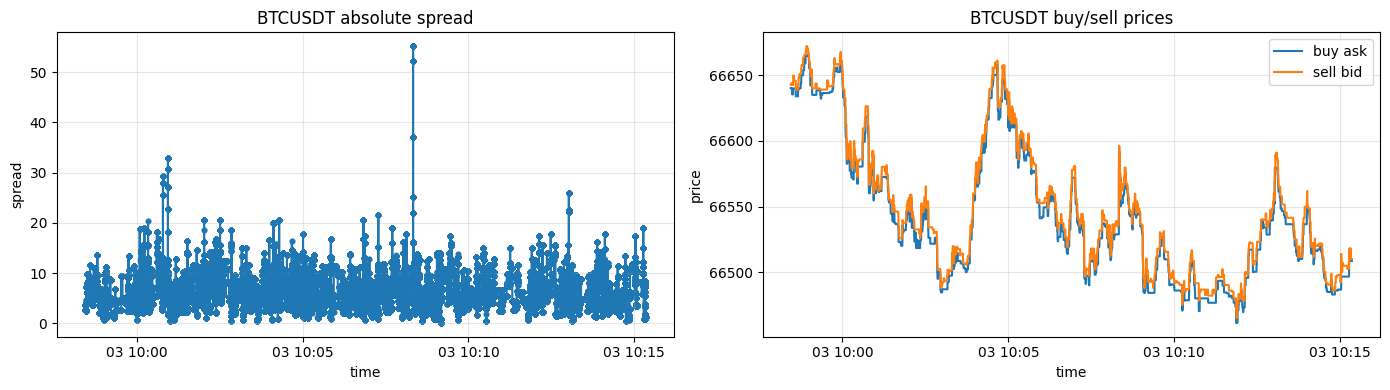

In [68]:
if df.empty:
    display("No data to plot.")
else:
    symbols = sorted(df["symbol"].unique())
    max_points_per_symbol = int(df.groupby("symbol").size().max())

    if max_points_per_symbol <= 1:
        summary = df.copy()
        summary["label"] = summary["symbol"] + "\n" + summary["buy_venue"] + " -> " + summary["sell_venue"]
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].bar(summary["label"], summary["spread_abs"], color="tab:green")
        axes[0].set_title("Latest arbitrage candidate absolute spread")
        axes[0].set_ylabel("spread")
        axes[0].grid(True, axis="y", alpha=0.3)

        axes[1].scatter(summary["buy_price"], summary["sell_price"], color="tab:blue")
        for _, row in summary.iterrows():
            axes[1].annotate(row["symbol"], (row["buy_price"], row["sell_price"]))
        axes[1].set_title("Latest candidate buy vs sell price")
        axes[1].set_xlabel("buy ask")
        axes[1].set_ylabel("sell bid")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        fig, axes = plt.subplots(len(symbols), 2, figsize=(14, 4 * len(symbols)), squeeze=False)
        for row_index, symbol in enumerate(symbols):
            symbol_df = df[df["symbol"] == symbol]

            ax_spread = axes[row_index][0]
            ax_spread.plot(symbol_df["ts_book_dt"], symbol_df["spread_abs"], label="spread_abs")
            ax_spread.scatter(symbol_df["ts_book_dt"], symbol_df["spread_abs"], s=10)
            ax_spread.set_title(f"{symbol} absolute spread")
            ax_spread.set_xlabel("time")
            ax_spread.set_ylabel("spread")
            ax_spread.grid(True, alpha=0.3)

            ax_prices = axes[row_index][1]
            ax_prices.plot(symbol_df["ts_book_dt"], symbol_df["buy_price"], label="buy ask")
            ax_prices.plot(symbol_df["ts_book_dt"], symbol_df["sell_price"], label="sell bid")
            ax_prices.set_title(f"{symbol} buy/sell prices")
            ax_prices.set_xlabel("time")
            ax_prices.set_ylabel("price")
            ax_prices.grid(True, alpha=0.3)
            ax_prices.legend()

        plt.tight_layout()
        plt.show()
